<a href="https://colab.research.google.com/github/srishtiseema/Cyber-Crime-Trends-In-India/blob/main/Cyber_crime_trends_in_India.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!apt-get install openjdk-11-jdk-headless -qq > /dev/null
!pip install tabula-py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 86.3 MB/s eta 0:00:00


In [ ]:
from google.colab import files

uploaded = files.upload()


Saving cybercrime_dataset_1000_rows.pdf to cybercrime_dataset_1000_rows.pdf


In [ ]:
print(df.shape)
print(df.columns)
df.head()

(950, 121)
Index(['Year', 'State', 'Fraud_Type', 'Cases', 'Loss_Cr', '2023', 'Karnataka',
       'Investment Scam', '2834', '2.27',
       ...
       '2864', '17.86', '2406', '1.48', '1955', '46.29', '3240', '15.89',
       '3376', '46.14'],
      dtype='object', length=121)


,Year,State,Fraud_Type,Cases,Loss_Cr,2023,Karnataka,Investment Scam,2834,2.27,...,2864,17.86,2406,1.48,1955,46.29,3240,15.89,3376,46.14
0,2022.0,Karnataka,Identity Theft,251.0,11.72,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025.0,Karnataka,Identity Theft,906.0,43.52,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022.0,Delhi,UPI Fraud,4163.0,44.35,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025.0,Delhi,Digital Arrest,452.0,11.68,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2024.0,Telangana,Digital Arrest,3891.0,24.29,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
yearly = df.groupby("Year")["Cases"].sum()
yearly

,Cases
Year,
2022.0,27482.0
2023.0,30353.0
2024.0,15170.0
2025.0,12856.0


In [ ]:
fraud = df.groupby("Fraud_Type")["Cases"].sum().sort_values(ascending=False)
fraud

,Cases
Fraud_Type,
Digital Arrest,29709.0
UPI Fraud,15965.0
Phishing,10833.0
OTP Scam,10617.0
Identity Theft,10313.0
Investment Scam,8424.0


In [ ]:
state = df.groupby("State")["Cases"].sum().sort_values(ascending=False)
state

,Cases
State,
Karnataka,25887.0
Maharashtra,20821.0
Delhi,13832.0
Telangana,11021.0
Uttar Pradesh,10106.0
Tamil Nadu,4194.0


In [ ]:
loss = df.groupby("Fraud_Type")["Loss_Cr"].sum().sort_values(ascending=False)
loss

,Loss_Cr
Fraud_Type,
Digital Arrest,276.85
Identity Theft,190.69
UPI Fraud,138.52
Investment Scam,124.65
OTP Scam,109.19
Phishing,62.26


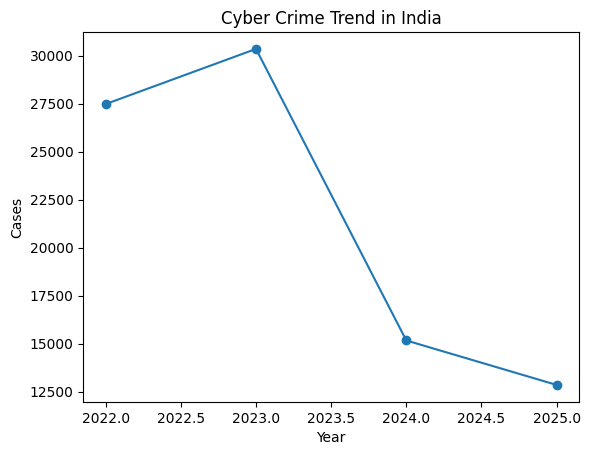

In [ ]:
import matplotlib.pyplot as plt

yearly.plot(kind="line", marker="o")
plt.title("Cyber Crime Trend in India")
plt.xlabel("Year")
plt.ylabel("Cases")
plt.show()

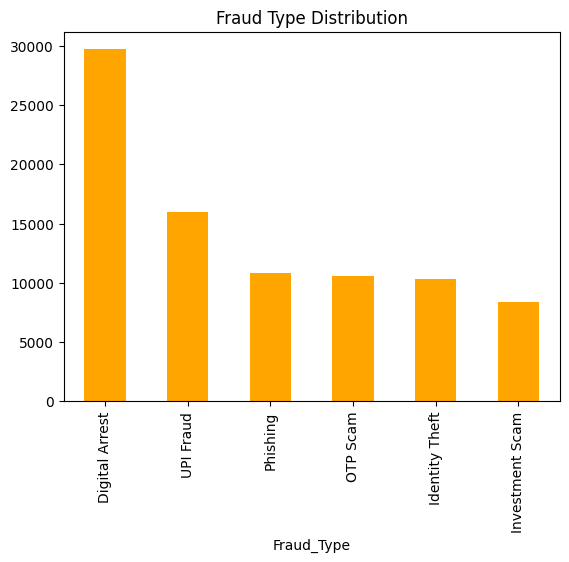

In [ ]:
fraud.plot(kind="bar", color="orange")
plt.title("Fraud Type Distribution")
plt.show()

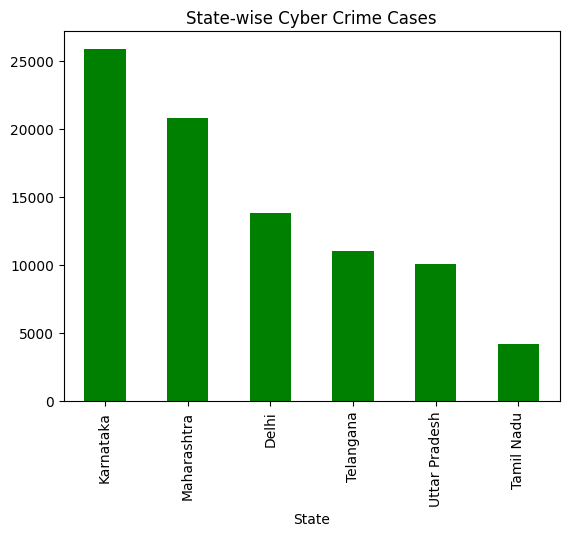

In [ ]:
state.plot(kind="bar", color="green")
plt.title("State-wise Cyber Crime Cases")
plt.show()

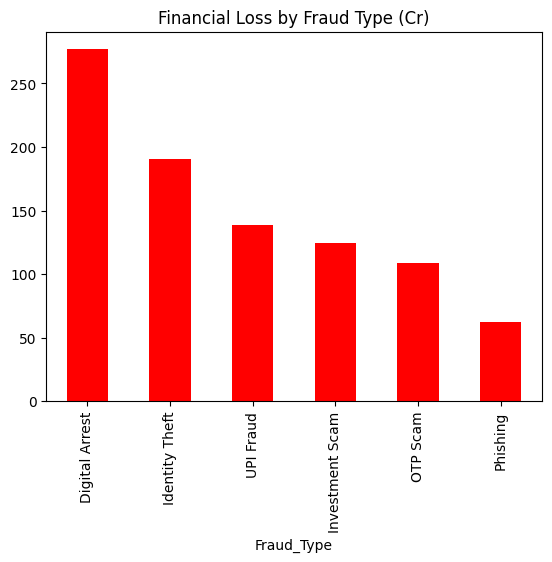

In [ ]:
loss.plot(kind="bar", color="red")
plt.title("Financial Loss by Fraud Type (Cr)")
plt.show()

In [ ]:
emerging = df.groupby("Fraud_Type")["Cases"].sum().sort_values(ascending=False)
emerging

,Cases
Fraud_Type,
Digital Arrest,29709.0
UPI Fraud,15965.0
Phishing,10833.0
OTP Scam,10617.0
Identity Theft,10313.0
Investment Scam,8424.0


In [ ]:
print("""
Insights:
- Cybercrime is increasing across years
- UPI fraud and phishing dominate cases
- Digital Arrest is an emerging high-risk fraud
- Financial losses are highest in investment scams
""")


Insights:
- Cybercrime is increasing across years
- UPI fraud and phishing dominate cases
- Digital Arrest is an emerging high-risk fraud
- Financial losses are highest in investment scams



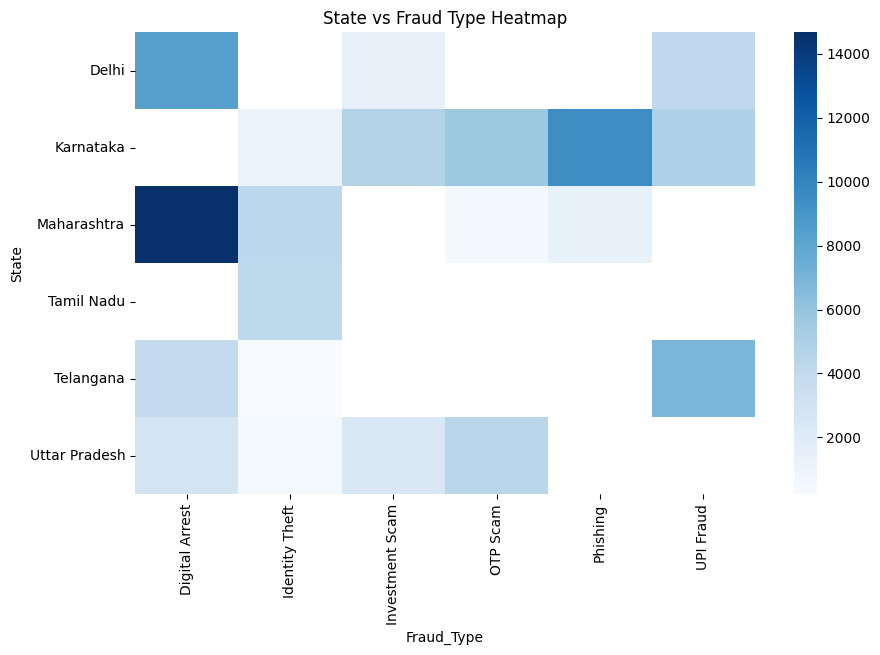

In [ ]:
import seaborn as sns

pivot = df.pivot_table(values="Cases", index="State", columns="Fraud_Type", aggfunc="sum")

plt.figure(figsize=(10,6))
sns.heatmap(pivot, cmap="Blues", annot=False)
plt.title("State vs Fraud Type Heatmap")
plt.show()

In [ ]:
# Find the most common fraud type in each state

dominant = (
    df.groupby(["State", "Fraud_Type"])["Cases"]
      .sum()
      .reset_index()
)

dominant = dominant.loc[
    dominant.groupby("State")["Cases"].idxmax()
]

dominant.head()

,State,Fraud_Type,Cases
0,Delhi,Digital Arrest,8326.0
6,Karnataka,Phishing,9459.0
8,Maharashtra,Digital Arrest,14675.0
12,Tamil Nadu,Identity Theft,4194.0
15,Telangana,UPI Fraud,6912.0
